## Polynomial Regression from Scratch

### Why Polynomial Features?
A linear model in the original feature space can only fit straight lines/planes.
If the relationship between $x$ and $y$ is nonlinear, we can map input $x$ to polynomial features:

$$
\phi(x) = [x, x^2, x^3, \dots, x^d]
$$

Then fit a linear model in transformed space:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d
$$

This is still linear in parameters $\theta$, so gradient descent applies directly.

In [9]:
from polynomial_example import generate_dataset
import numpy as np

random_generator = np.random.default_rng(42)
inputs_raw, outputs = generate_dataset(random_generator, dataset_size=300)


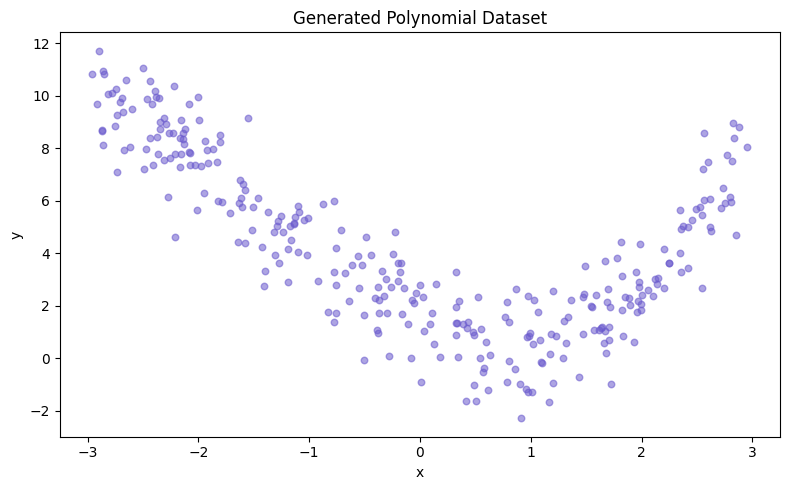

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(inputs_raw, outputs, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [19]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
scaler = StandardScaler()
inputs_with_polynomial_features = scaler.fit_transform(
    poly.fit_transform(inputs_raw)
)
inputs = add_bias_term_to_inputs(inputs_with_polynomial_features)

In [34]:
from shared import (
    train_weights,
    add_bias_term_to_inputs,
    create_batch_gradient_descent_compute_new_weights_function,
    create_mini_batch_gradient_descent_compute_new_weights_function,
    create_stochastic_gradient_descent_compute_new_weights_function,
)
epochs = 250
results_simple = []

batch_result = train_weights(
    inputs,
    initial_weights=np.zeros((inputs.shape[1], 1)),
    outputs=outputs,
    epochs=epochs,
    compute_new_weights_function=create_batch_gradient_descent_compute_new_weights_function(
        learning_rate=0.05
    )
)
results_simple.append({
    "Method": "batch",
    "Final MSE": batch_result.loss_history[-1],
    "Training Time (s)": batch_result.training_time,
    "Final Weights": batch_result.weights.ravel(),
    "Epochs to Converge": next((i + 1 for i, l in enumerate(batch_result.loss_history) if l <= 1.05 * batch_result.loss_history[-1]), epochs)
})

mini_batch_result = train_weights(
    inputs,
    initial_weights=np.zeros((inputs.shape[1], 1)),
    outputs=outputs,
    epochs=epochs,
    compute_new_weights_function=create_mini_batch_gradient_descent_compute_new_weights_function(
        learning_rate=0.005,
        random_generator=random_generator,
        batch_size=32
    )
)
results_simple.append({
    "Method": "mini-batch",
    "Final MSE": mini_batch_result.loss_history[-1],
    "Training Time (s)": mini_batch_result.training_time,
    "Final Weights": mini_batch_result.weights.ravel(),
    "Epochs to Converge": next((i + 1 for i, l in enumerate(mini_batch_result.loss_history) if l <= 1.05 * mini_batch_result.loss_history[-1]), epochs)
})

stochastic_result = train_weights(
    inputs,
    initial_weights=np.zeros((inputs.shape[1], 1)),
    outputs=outputs,
    epochs=epochs,
    compute_new_weights_function=create_stochastic_gradient_descent_compute_new_weights_function(
        learning_rate=0.02,
        random_generator=random_generator,
    )
)
results_simple.append({
    "Method": "stochastic",
    "Final MSE": stochastic_result.loss_history[-1],
    "Training Time (s)": stochastic_result.training_time,
    "Final Weights": stochastic_result.weights.ravel(),
    "Epochs to Converge": next((i + 1 for i, l in enumerate(stochastic_result.loss_history) if l <= 1.05 * stochastic_result.loss_history[-1]), epochs)
})

import pandas as pd
result_df = pd.DataFrame(results_simple)
result_df

,Method,Final MSE,Training Time (s),Final Weights,Epochs to Converge
0,batch,1.628774,0.007785,"[4.246974929381943, -2.4881995465709323, 2.276...",200
1,mini-batch,1.628655,0.016992,"[4.245008132244571, -2.4875169745486114, 2.276...",200
2,stochastic,1.496450,0.284253,"[4.132278715274098, -3.5163811304989263, 2.427...",3


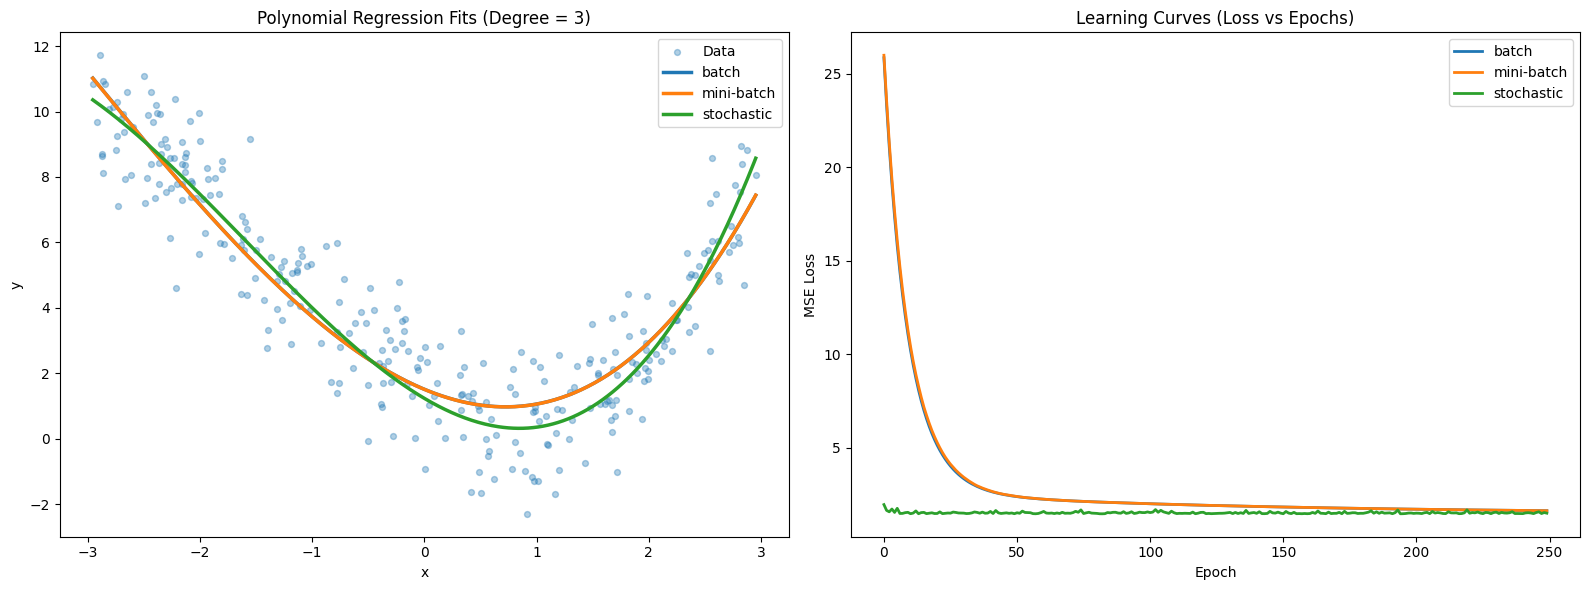

,Method,Final MSE,Training Time (s),Final Weights,Epochs to Converge
2,stochastic,1.496450,0.284253,"[4.132278715274098, -3.5163811304989263, 2.427...",3
1,mini-batch,1.628655,0.016992,"[4.245008132244571, -2.4875169745486114, 2.276...",200
0,batch,1.628774,0.007785,"[4.246974929381943, -2.4881995465709323, 2.276...",200


In [36]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(inputs_raw.min(), inputs_raw.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(inputs_raw, outputs, alpha=0.35, s=18, label="Data")
axes[0].plot(x_grid, X_grid_design @ batch_result.weights, linewidth=2.5, label="batch")
axes[0].plot(x_grid, X_grid_design @ mini_batch_result.weights, linewidth=2.5, label="mini-batch")
axes[0].plot(x_grid, X_grid_design @ stochastic_result.weights, linewidth=2.5, label="stochastic")

axes[0].set_title("Polynomial Regression Fits (Degree = 3)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].plot(batch_result.loss_history, linewidth=2, label="batch")
axes[1].plot(mini_batch_result.loss_history, linewidth=2, label="mini-batch")
axes[1].plot(stochastic_result.loss_history, linewidth=2, label="stochastic")

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

display(result_df.sort_values("Final MSE"))